In [266]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from sklearn.metrics import make_scorer
import random
import joblib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
TRA = pd.read_csv("Data/TrainingData.csv")

In [3]:
TRA

,Driver,Constructor,AveragePositionFromLast3Races,AveragePointsFromLast3Races,ConstructorAveragePointFromLast3Races,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),...,Sector1_Rank,Sector2_Rank,Sector3_Rank,CombinedSectorTime,CombinedSectorDelta,LapTime_Rank,DeltaToFastestLap,StartXConst,DriXConst,FP3XStart
0,ALB,Williams,11.000000,0.000000,0.0,83.130,81.847,81.664,36.650031,20.898312,...,8,11,9,100.490737,4.395648,11,8.162887,0.0,0.0,240.0
1,ALO,Aston Martin,11.000000,0.000000,0.0,82.065,84.662,82.720,35.042333,23.232611,...,3,18,18,108.596878,12.501790,18,13.597315,0.0,0.0,289.0
2,ANT,Mercedes,11.000000,0.000000,0.0,81.376,79.943,80.324,36.042935,19.788161,...,5,1,4,97.629652,1.534564,3,3.429035,0.0,0.0,12.0
3,BEA,Haas F1 Team,11.000000,0.000000,0.0,82.682,81.326,80.778,39.039839,20.835774,...,15,10,5,101.749399,5.654310,17,9.836708,0.0,0.0,108.0
4,BOR,Audi,11.000000,0.000000,0.0,81.696,81.668,80.459,39.209964,20.777286,...,17,8,17,106.696170,10.601082,9,7.313140,0.0,0.0,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,PIA,McLaren,4.666667,9.833333,16.5,75.565,74.088,73.698,23.133323,40.818367,...,10,12,21,91.649578,6.159030,16,6.427093,742.0,5088.0,42.0
125,RUS,Mercedes,7.666667,9.833333,31.0,74.983,73.405,73.483,23.428030,42.588500,...,15,21,6,90.983917,5.493369,9,4.352733,1314.0,19272.0,24.0
126,SAI,Williams,6.666667,4.333333,2.5,76.041,74.512,74.336,22.817939,41.192212,...,4,13,16,90.523252,5.032703,15,6.288971,84.0,42.0,144.0
127,STR,Aston Martin,10.666667,5.333333,0.0,77.556,76.174,75.921,23.562741,40.432074,...,16,7,1,86.583975,1.093426,4,2.050431,0.0,0.0,484.0


In [4]:
X = TRA.drop(["Driver","Constructor","Race_Result"],axis=1)

In [5]:
X.columns

Index(['AveragePositionFromLast3Races', 'AveragePointsFromLast3Races',
       'ConstructorAveragePointFromLast3Races', 'FP1_BestTime(s)',
       'FP2_BestTime(s)', 'FP3_BestTime(s)', 'Sector1Time(s)',
       'Sector2Time(s)', 'Sector3Time(s)', 'Average_Laptime(s)',
       'Qualifying_Time(s)', 'Starting_Pos', 'DriverPoints',
       'ConstructorPoints', 'FP1_Rank', 'FP2_Rank', 'FP3_Rank',
       'FP1_DeltaToFastest', 'FP2_DeltaToFastest', 'FP3_DeltaToFastest',
       'Sector1_Rank', 'Sector2_Rank', 'Sector3_Rank', 'CombinedSectorTime',
       'CombinedSectorDelta', 'LapTime_Rank', 'DeltaToFastestLap',
       'StartXConst', 'DriXConst', 'FP3XStart'],
      dtype='object')

In [6]:
y = TRA["Race_Result"]

In [7]:
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed , y, test_size = 0.25, random_state = 23)

In [14]:
X_test.shape

(33, 30)

In [15]:
X_train.shape

(96, 30)

In [97]:
model = RandomForestRegressor()

In [98]:
param_grid = {
    'max_depth':[2],
    'min_samples_split':[9],
    'max_features':[4]
}

In [99]:
regcv = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

In [100]:
regcv.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [2], 'max_features': [4], 'min_samples_split': [9]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [101]:
y_pred = regcv.predict(X_test)

In [102]:
corr, _ = spearmanr(y_pred, y_test)
print("Spearman Rank:", corr)

Spearman Rank: 0.49660959375829283


In [103]:
joblib.dump(model,"Model/BaseRandomForest.pkl")

['Model/BaseRandomForest.pkl']

In [104]:
model = Ridge()

In [105]:
param_grid = {
    "alpha": [ 0.01, 0.1, 1, 10, 25, 50, 100, 250, 500],
    "fit_intercept": [True, False],
    "solver": ["auto", "svd", "cholesky", "lsqr"]
}

In [106]:
regcv = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

In [107]:
regcv.fit(X_train, y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.01, 0.1, ...], 'fit_intercept': [True, False], 'solver': ['auto', 'svd', ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,500


In [108]:
regcv.best_params_

{'alpha': 500, 'fit_intercept': False, 'solver': 'lsqr'}

In [109]:
y_pred = regcv.predict(X_test)

In [110]:
corr, _ = spearmanr(y_pred, y_test)
print("Spearman Rank:", corr)

Spearman Rank: 0.5428369960777831


In [113]:
joblib.dump(model,"Model/BaseRidge.pkl")

['Model/BaseRidge.pkl']

In [268]:
columns = [ 'AveragePointsFromLast3Races',
       'ConstructorAveragePointFromLast3Races', 'FP1_BestTime(s)',
       'FP2_BestTime(s)', 'FP3_BestTime(s)',
       'Qualifying_Time(s)', 'Starting_Pos', 'DriverPoints',
       'ConstructorPoints', 'FP1_Rank', 'FP2_Rank', 'FP3_Rank',
       'FP1_DeltaToFastest', 'FP2_DeltaToFastest', 'FP3_DeltaToFastest',
       'Sector1_Rank',
       'StartXConst', 'DriXConst', 'FP3XStart']

In [269]:
X = TRA[columns]

In [270]:
X.columns

Index(['AveragePointsFromLast3Races', 'ConstructorAveragePointFromLast3Races',
       'FP1_BestTime(s)', 'FP2_BestTime(s)', 'FP3_BestTime(s)',
       'Qualifying_Time(s)', 'Starting_Pos', 'DriverPoints',
       'ConstructorPoints', 'FP1_Rank', 'FP2_Rank', 'FP3_Rank',
       'FP1_DeltaToFastest', 'FP2_DeltaToFastest', 'FP3_DeltaToFastest',
       'Sector1_Rank', 'StartXConst', 'DriXConst', 'FP3XStart'],
      dtype='object')

In [271]:
imputer = SimpleImputer(strategy="median")

In [272]:
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size = 0.25, random_state = 23)

In [273]:
X_train_imputed = imputer.fit_transform(X_train)

In [274]:
X_test_imputed = imputer.transform(X_test)

In [309]:
model = Ridge()

In [310]:
param_grid = {
    "alpha": [ 0.01, 0.1, 1, 10, 25, 50, 100, 250, 500, 1000, 5000, 10000],
    "fit_intercept": [True, False],
    "solver": ["auto", "svd", "cholesky", "lsqr"],
    "max_iter":[100,200,500,1000,10000,100000],
    "positive": [True,False]
}

In [311]:
def spearman_correlation(y_true,y_pred):
    return spearmanr(y_true,y_pred)[0]

spearman_scorer = make_scorer(spearman_correlation, greater_is_better=True)

In [312]:
regcv = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring=spearman_scorer
)

In [313]:
regcv.fit(X_train_imputed, y_train)

/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
2160 fits failed out of a total of 5760.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
720 fits failed with the following error:
Traceback (most recent call last):
  File "/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/linear_mo

,estimator,Ridge()
,param_grid,"{'alpha': [0.01, 0.1, ...], 'fit_intercept': [True, False], 'max_iter': [100, 200, ...], 'positive': [True, False], ...}"
,scoring,make_scorer(s...hod='predict')
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,5000


In [314]:
regcv.best_params_

{'alpha': 5000,
 'fit_intercept': True,
 'max_iter': 100,
 'positive': True,
 'solver': 'auto'}

In [315]:
y_pred = regcv.predict(X_test_imputed)

In [316]:
corr, _ = spearmanr(y_pred, y_test)
print("Spearman Rank:", corr)

Spearman Rank: 0.5905718136903003


In [297]:
joblib.dump(model, "Model/BetterRodge.pkl")

['Model/BetterRodge.pkl']

In [320]:
best_model = regcv.best_estimator_

feature_importance = pd.Series(
    best_model.coef_,
    index=X.columns
)

feature_importance.sort_values(key=abs, ascending=False)
features = X.columns

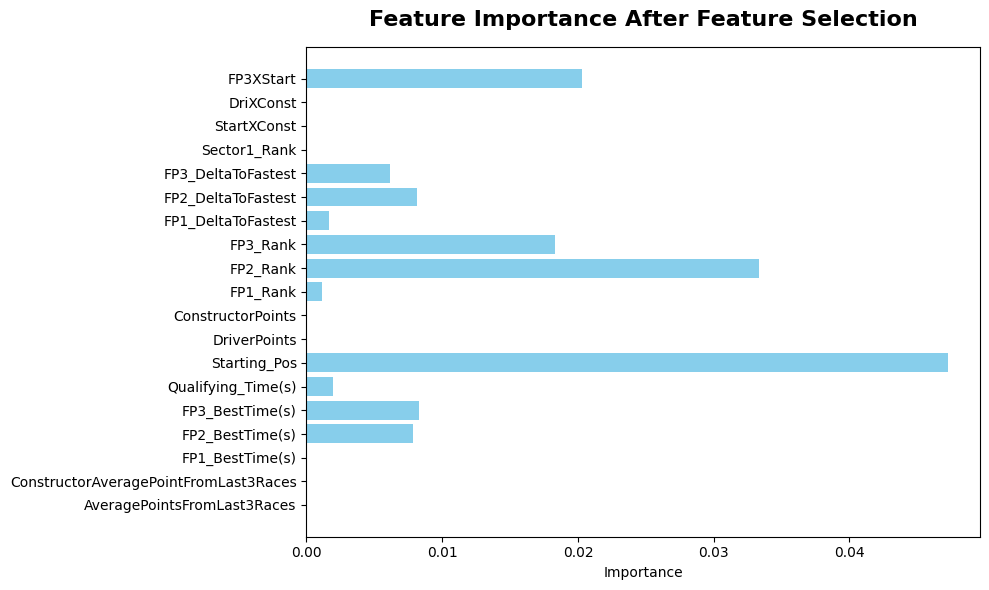

In [321]:


plt.figure(figsize=(10,6))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance After Feature Selection", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("Plots/Feature_importance_in_2nd_itration.png", dpi=300, bbox_inches='tight')
plt.show()

In [322]:
PRE = pd.read_csv("Data/PredictionData.csv")

In [323]:
X = PRE[columns]

In [324]:
X_imputed = imputer.transform(X)

In [325]:
y_pred = regcv.predict(X_imputed)

In [326]:
PRE["Predicted_Result"] = y_pred

In [327]:
PRE = PRE.sort_values(by="Predicted_Result", ascending=True)
PRE = PRE.reset_index(drop=True)
PRE["Predicted_Pos"] = PRE.index + 1

In [328]:
PRE

,Driver,Constructor,AveragePositionFromLast3Races,AveragePointsFromLast3Races,ConstructorAveragePointFromLast3Races,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),...,Sector3_Rank,CombinedSectorTime,CombinedSectorDelta,LapTime_Rank,DeltaToFastestLap,StartXConst,DriXConst,FP3XStart,Predicted_Result,Predicted_Pos
0,RUS,Mercedes,10.333333,5.166667,25.0,76.363,75.435,75.679,27.795167,37.480964,...,11,94.875238,5.089900,3,5.532107,244.0,21472.0,1.0,7.365742,1
1,NOR,McLaren,12.333333,6.166667,5.0,78.172,75.426,75.925,32.221370,38.061300,...,8,99.562570,9.777233,15,11.391453,464.0,6728.0,16.0,7.851850,2
2,HAM,Ferrari,7.333333,12.666667,24.0,78.172,76.631,76.381,35.381200,41.650393,...,18,107.606950,17.821612,20,14.096562,330.0,14850.0,10.0,7.944520,3
3,PIA,McLaren,5.333333,7.666667,5.0,76.566,75.483,75.893,30.272450,36.083208,...,12,96.200617,6.415279,5,7.181265,812.0,6728.0,14.0,7.970931,4
4,ANT,Mercedes,9.000000,17.000000,25.0,78.172,76.015,76.500,30.541731,36.241452,...,4,95.424924,5.639587,4,6.138507,732.0,38064.0,21.0,8.113078,5
5,VER,Red Bull Racing,13.333333,6.666667,18.5,77.047,76.321,76.434,28.601367,35.599091,...,1,91.193882,1.408544,1,0.000000,345.0,2967.0,30.0,8.398490,6
6,LEC,Ferrari,11.000000,5.500000,24.0,76.883,75.799,75.922,33.514920,36.843536,...,7,99.361835,9.576497,16,12.758187,1650.0,12375.0,30.0,8.496633,7
7,HAD,Red Bull Racing,6.333333,9.166667,18.5,78.172,76.674,76.684,30.813000,38.688500,...,19,100.118633,10.333296,13,9.867787,414.0,1794.0,48.0,8.996721,8
8,HUL,Audi,8.333333,4.166667,0.0,78.172,76.934,76.961,29.548333,37.388677,...,5,95.597172,5.811834,9,9.081811,18.0,0.0,81.0,9.872489,9
9,LAW,Racing Bulls,6.333333,7.166667,10.0,77.472,76.967,77.324,27.451800,38.549143,...,22,105.547193,15.761855,14,11.356507,280.0,840.0,96.0,10.251200,10


In [329]:
PRE.to_csv("Data/PredictedData.csv",index=False)

In [331]:
podium = PRE.loc[:,["Driver"]]
print("\n Predicted Standing")
print(f"🥇P1: {podium.iloc[0]['Driver']}")
print(f"🥈P2: {podium.iloc[1]['Driver']}")
print(f"🥉P3: {podium.iloc[2]['Driver']}")
print(f"P4: {podium.iloc[3]['Driver']}")
print(f"P5: {podium.iloc[4]['Driver']}")
print(f"P6: {podium.iloc[5]['Driver']}")
print(f"P7: {podium.iloc[6]['Driver']}")
print(f"P8: {podium.iloc[7]['Driver']}")
print(f"P9: {podium.iloc[8]['Driver']}")
print(f"P10: {podium.iloc[9]['Driver']}")
print(f"P11: {podium.iloc[10]['Driver']}")
print(f"P12: {podium.iloc[11]['Driver']}")

print(f"Spearman Rank (Predicted): {corr:.2f}")


 Predicted Standing
🥇P1: RUS
🥈P2: NOR
🥉P3: HAM
P4: PIA
P5: ANT
P6: VER
P7: LEC
P8: HAD
P9: HUL
P10: LAW
P11: LIN
P12: BOR
Spearman Rank (Predicted): 0.59
